<a href="https://colab.research.google.com/github/choudharyshweta0420-creator/Emergency-Department-Analytics/blob/main/ED_Analytics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project
## Emergency Department Analytics: From Statistics to Predictive Models

**Estimated time:** 1 hour

## Load dataset

In [14]:
import pandas as pd
df = pd.read_csv("https://statistical-analysis-and-data-modeling-in-healthcare-02a43a.gitlab.io/labs/final-project/ed_project_data.csv")
df.head()

,visit_id,age,triage_level,arrival_hr,ed_los_hours,num_tests_ordered,admitted
0,1,65,High,3,7.39,2,1
1,2,86,Medium,14,3.12,1,1
2,3,43,Medium,18,6.03,3,0
3,4,85,Low,0,2.74,2,1
4,5,41,High,15,9.45,1,0


## ✅ Task 1: Inspect dataset dimensions and column types

Write code that explicitly prints the number of rows and columns in the dataset, followed by code that displays the data type of every column. Your output should clearly show the dataset size and whether each variable is numeric or categorical.

In [15]:
# Check dataset size
print("Rows and columns:", df.shape)

# Check variable types
df.dtypes

Rows and columns: (400, 7)


,0
visit_id,int64
age,int64
triage_level,object
arrival_hr,int64
ed_los_hours,float64
num_tests_ordered,int64
admitted,int64


## ✅ Task 2: Summarize ED length of stay

Write code that calculates the mean (average) and the median of the `ed_los_hours` column. Display both values clearly so that they can be compared.

In [16]:
# Calculate mean and median ED length of stay

mean_los = df['ed_los_hours'].mean()
median_los = df['ed_los_hours'].median()

print("Mean ED LOS (hours):", mean_los)
print("Median ED LOS (hours):", median_los)

Mean ED LOS (hours): 5.0272
Median ED LOS (hours): 4.535


## ✅ Task 3: Compare LOS by admission status

Create a visualization that compares the distribution of emergency department length of stay (`ed_los_hours`) for patients who were admitted versus those who were not. A boxplot or similar comparison plot is expected.

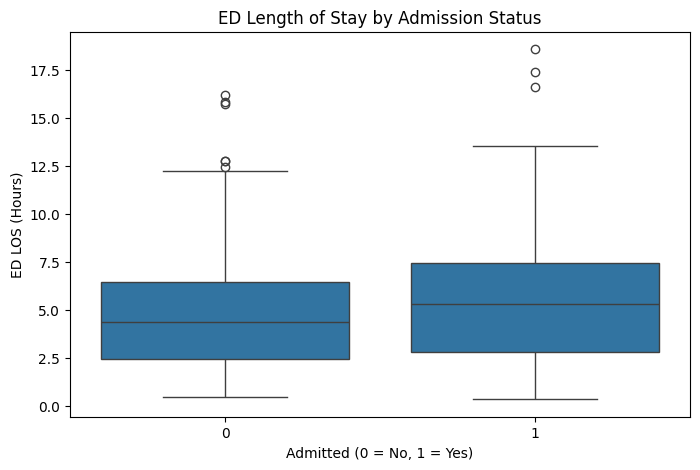

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x='admitted',
    y='ed_los_hours',
    data=df
)

plt.title("ED Length of Stay by Admission Status")
plt.xlabel("Admitted (0 = No, 1 = Yes)")
plt.ylabel("ED LOS (Hours)")

plt.show()

## ✅ Task 4: Hypothesis test - Admission versus LOS

Perform an appropriate statistical hypothesis test to determine whether the mean emergency department length of stay differs between admitted and non-admitted patients. Report the test statistic and p-value.

In [18]:
from scipy.stats import ttest_ind

admitted_los = df[df['admitted'] == 1]['ed_los_hours']

non_admitted_los = df[df['admitted'] == 0]['ed_los_hours']


t_stat, p_value = ttest_ind(
    admitted_los,
    non_admitted_los
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 2.070187862215528
P-value: 0.03907921131137012


## ✅ Task 5: ANOVA - LOS across triage levels

Use a one-way ANOVA to test whether the mean emergency department length of stay differs across the Low, Medium, and High triage categories. Output the F-statistic and p-value.

In [19]:
from scipy.stats import f_oneway

groups = []

for level in df['triage_level'].unique():
    groups.append(
        df[df['triage_level'] == level]['ed_los_hours']
    )


anova_result = f_oneway(*groups)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

F-statistic: 0.12082761585672012
P-value: 0.8862192870513664


## ✅ Task 6: Logistic regression - Admission risk

Build and train a logistic regression model that predicts the binary `admitted` outcome using `age`, `ed_los_hours`, and `num_tests_ordered` as predictors. Use the variable name logistic_model to refer your model. Print the accuracy of the model using logistic_model.score(X,y).

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Select predictors and target
X = df[['age', 'ed_los_hours', 'num_tests_ordered']]
y = df['admitted']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create and train logistic regression model
logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

# Calculate accuracy
accuracy = logistic_model.score(X_test, y_test)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.7


## ✅ Task 7: Evaluate admission model (AUC)

Using the trained logistic regression model created earlier, generate predicted probabilities for admission and compute the ROC–AUC score. Display the numeric AUC value.

In [21]:
from sklearn.metrics import roc_auc_score

# Generate predicted probabilities
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.6495535714285714


## ✅ Task 8: Decision tree model

Train a decision tree classification model that predicts the `admitted` outcome using the same predictors as the logistic regression model. Ensure the model is fitted without errors. Use the variable name decision_tree_model to refer your model. Print the accuracy of the model using decision_tree_model.score(X,y).

In [22]:
from sklearn.tree import DecisionTreeClassifier

# Create decision tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train model
decision_tree_model.fit(X_train, y_train)

# Calculate accuracy
dt_accuracy = decision_tree_model.score(X_test, y_test)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.6125


## ✅ Task 9: Random forest comparison

Train a random forest classifier classification model that predicts the admitted outcome using the same predictors as the logistic regression model. Ensure the model is fitted without errors. Use the variable name random_forest_model to refer your model. Print the accuracy of the model using random_forest_model.score(X,y).

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Create random forest model
random_forest_model = RandomForestClassifier(
    random_state=42
)

# Train model
random_forest_model.fit(X_train, y_train)

# Calculate accuracy
rf_accuracy = random_forest_model.score(X_test, y_test)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.65


## ✅ Task 10: Operational interpretation

Based on your analysis of the ED operation team data which of the following statements/option is correct?

A. Patients with longer emergency department length of stay and a higher number of diagnostic tests have an increased likelihood of hospital admission, suggesting these variables can be used for early risk stratification.

B. Age alone is sufficient to predict hospital admission, and length of stay does not contribute meaningful information beyond patient demographics.

C. Admission decisions appear to be random and cannot be meaningfully predicted using triage level, length of stay, or diagnostic testing data.

D. Statistical tests show no measurable differences in length of stay across patient groups, indicating that predictive modeling is not appropriate for this dataset.

### Task 10: Operational Interpretation

**Correct Answer: A**

Patients with longer emergency department length of stay and a higher number of diagnostic tests have an increased likelihood of hospital admission, suggesting these variables can be used for early risk stratification.

The analysis showed that predictive modeling can identify patterns associated with admission risk. Variables such as ED length of stay and number of tests ordered provided useful information for predicting hospital admission and supporting emergency department resource planning.